In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv("fight_hist.csv")

# View first rows
df.head()

,date,fight_url,event_url,result,fighter,opponent,division,method,round,time,fighter_url,opponent_url,knockdowns,sub_attempts,reversals,control_time,takedowns_landed,takedowns_attempts,sig_strikes_landed,sig_strikes_attempts,total_strikes_landed,total_strikes_attempts,head_strikes_landed,head_strikes_attempts,body_strikes_landed,body_strikes_attempts,leg_strikes_landed,leg_strikes_attempts,distance_strikes_landed,distance_strikes_attempts,clinch_strikes_landed,clinch_strikes_attempts,ground_strikes_landed,ground_strikes_attempts
0,"April 13, 2024",http://ufcstats.com/fight-details/e4931f3ab3bf...,http://ufcstats.com/event-details/6750e338922a...,W,Alex Pereira,Jamahal Hill,Light Heavyweight,KO/TKO,1,3:14,http://ufcstats.com/fighter-details/e5549c82bf...,http://ufcstats.com/fighter-details/5444c5a201...,1,0,0,0:07,0,0,24,30,24,30,12,15,6,6,6,9,13,16,0,0,11,14
1,"April 13, 2024",http://ufcstats.com/fight-details/e4931f3ab3bf...,http://ufcstats.com/event-details/6750e338922a...,L,Jamahal Hill,Alex Pereira,Light Heavyweight,KO/TKO,1,3:14,http://ufcstats.com/fighter-details/5444c5a201...,http://ufcstats.com/fighter-details/e5549c82bf...,0,0,0,0:00,0,0,12,22,12,22,1,7,3,6,8,9,12,22,0,0,0,0
2,"April 13, 2024",http://ufcstats.com/fight-details/66eddbe35056...,http://ufcstats.com/event-details/6750e338922a...,W,Zhang Weili,Yan Xiaonan,Women's Strawweight,U-DEC,5,5:00,http://ufcstats.com/fighter-details/1ebe20ebbf...,http://ufcstats.com/fighter-details/c41d426cc7...,0,2,0,12:44,6,9,106,157,256,327,84,119,13,19,9,19,34,78,1,1,71,78
3,"April 13, 2024",http://ufcstats.com/fight-details/66eddbe35056...,http://ufcstats.com/event-details/6750e338922a...,L,Yan Xiaonan,Zhang Weili,Women's Strawweight,U-DEC,5,5:00,http://ufcstats.com/fighter-details/c41d426cc7...,http://ufcstats.com/fighter-details/1ebe20ebbf...,1,0,1,2:20,3,3,43,85,73,116,21,60,4,6,18,19,24,64,3,4,16,17
4,"April 13, 2024",http://ufcstats.com/fight-details/cf5e8f98159c...,http://ufcstats.com/event-details/6750e338922a...,W,Max Holloway,Justin Gaethje,Lightweight,KO/TKO,5,4:59,http://ufcstats.com/fighter-details/150ff4cc64...,http://ufcstats.com/fighter-details/9e8f6c728e...,1,0,0,0:00,0,0,181,309,181,309,62,149,62,91,57,69,181,308,0,1,0,0


In [3]:
# Check dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 15198 entries, 0 to 15197
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   date                       15198 non-null  str  
 1   fight_url                  15198 non-null  str  
 2   event_url                  15198 non-null  str  
 3   result                     15198 non-null  str  
 4   fighter                    15198 non-null  str  
 5   opponent                   15198 non-null  str  
 6   division                   15198 non-null  str  
 7   method                     15198 non-null  str  
 8   round                      15198 non-null  int64
 9   time                       15198 non-null  str  
 10  fighter_url                15198 non-null  str  
 11  opponent_url               15198 non-null  str  
 12  knockdowns                 15198 non-null  int64
 13  sub_attempts               15198 non-null  int64
 14  reversals                  15198 

date                         0
fight_url                    0
event_url                    0
result                       0
fighter                      0
opponent                     0
division                     0
method                       0
round                        0
time                         0
fighter_url                  0
opponent_url                 0
knockdowns                   0
sub_attempts                 0
reversals                    0
control_time                 0
takedowns_landed             0
takedowns_attempts           0
sig_strikes_landed           0
sig_strikes_attempts         0
total_strikes_landed         0
total_strikes_attempts       0
head_strikes_landed          0
head_strikes_attempts        0
body_strikes_landed          0
body_strikes_attempts        0
leg_strikes_landed           0
leg_strikes_attempts         0
distance_strikes_landed      0
distance_strikes_attempts    0
clinch_strikes_landed        0
clinch_strikes_attempts      0
ground_s

In [4]:
# Remove non-numeric identifiers if present
df = df.drop(columns=['fighter_name'], errors='ignore')

In [5]:
X = df.drop("result", axis=1)
y = df["result"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [11]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Keep only numeric columns (removes URLs, names, etc.)
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

# Create the model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_predictions))

print("\nClassification Report")
print(classification_report(y_test, dt_predictions, zero_division=0))

Decision Tree Accuracy: 0.7492105263157894

Confusion Matrix
[[   0   40   29]
 [   0 1478  421]
 [   0  463 1369]]

Classification Report
              precision    recall  f1-score   support

           D       0.00      0.00      0.00        69
           L       0.75      0.78      0.76      1899
           W       0.75      0.75      0.75      1832

    accuracy                           0.75      3800
   macro avg       0.50      0.51      0.50      3800
weighted avg       0.74      0.75      0.74      3800



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Create the model (handles class imbalance)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
rf_predictions = rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

# Classification Report (prevents warning)
print("\nClassification Report")
print(classification_report(y_test, rf_predictions, zero_division=0))

Random Forest Accuracy: 0.7760526315789473

Confusion Matrix
[[   0   36   33]
 [   0 1430  469]
 [   0  313 1519]]

Classification Report
              precision    recall  f1-score   support

           D       0.00      0.00      0.00        69
           L       0.80      0.75      0.78      1899
           W       0.75      0.83      0.79      1832

    accuracy                           0.78      3800
   macro avg       0.52      0.53      0.52      3800
weighted avg       0.76      0.78      0.77      3800



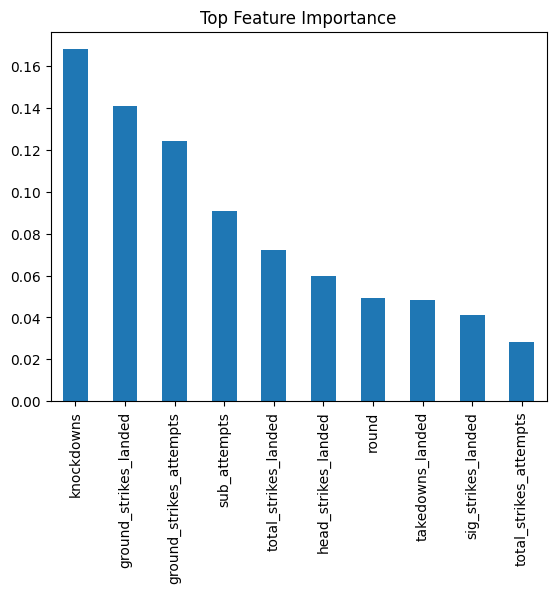

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf_model.feature_importances_
features = X_train.columns   # use the training dataset

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()